In [21]:
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
import plotly.express as px
plt.style.use("ggplot")

In [22]:
df= pd.read_csv("../data/cleaned_superstore.csv")

In [23]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [24]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 18  Quantity       9994

In [25]:
df["Order Date"] = pd.to_datetime(df["Order Date"])

In [26]:
df["Month"] = df["Order Date"].dt.to_period("M")

In [27]:
df[["Order Date","Month"]].head()

,Order Date,Month
0,2016-11-08,2016-11
1,2016-11-08,2016-11
2,2016-06-12,2016-06
3,2015-10-11,2015-10
4,2015-10-11,2015-10


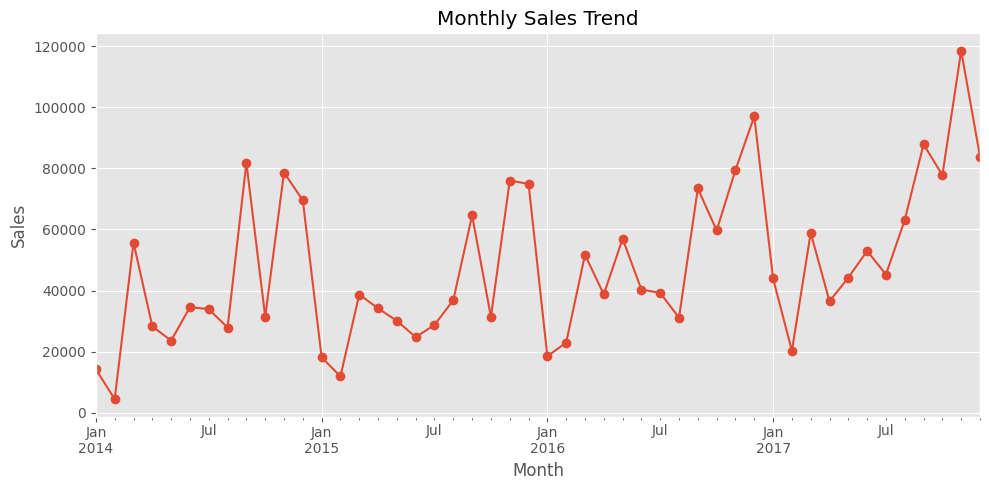

In [28]:
monthly_sales = df.groupby("Month")["Sales"].sum()

plt.figure(figsize=(10,5))

monthly_sales.plot(marker="o")

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.grid(True)

plt.tight_layout()

plt.savefig("../visualizations/line_chart.png")

plt.show()


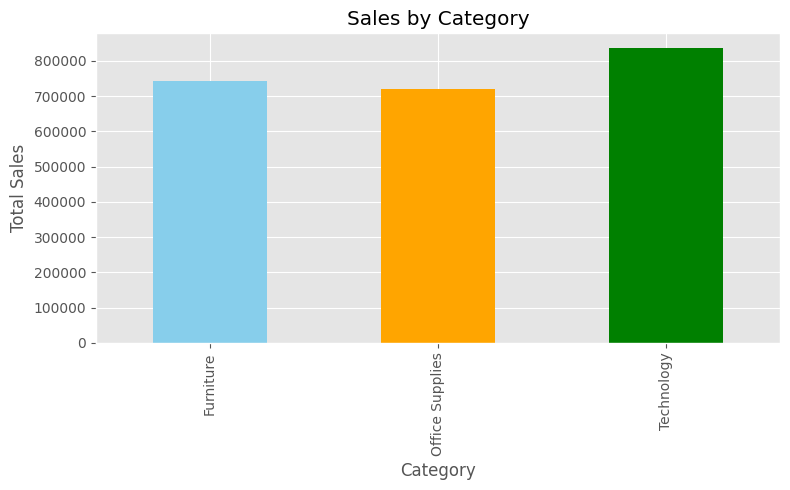

In [29]:
category_sales = df.groupby("Category")["Sales"].sum()

plt.figure(figsize=(8,5))

category_sales.plot(kind="bar", color=["skyblue","orange","green"])

plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")

plt.tight_layout()

plt.savefig("../visualizations/bar_chart.png")

plt.show()

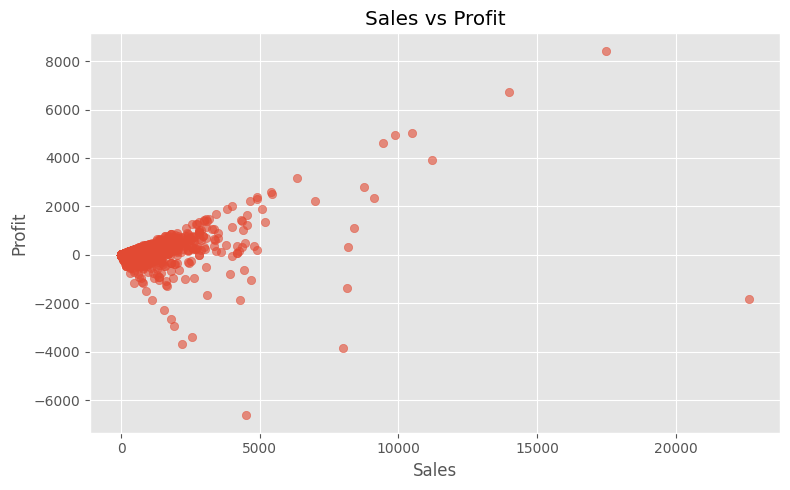

In [30]:
plt.figure(figsize=(8,5))

plt.scatter(df["Sales"],df["Profit"],alpha=0.6)
plt.title("Sales vs Profit")

plt.xlabel("Sales")
plt.ylabel("Profit")

plt.grid(True)
plt.tight_layout()

plt.savefig("../visualizations/scatter_plot.png")

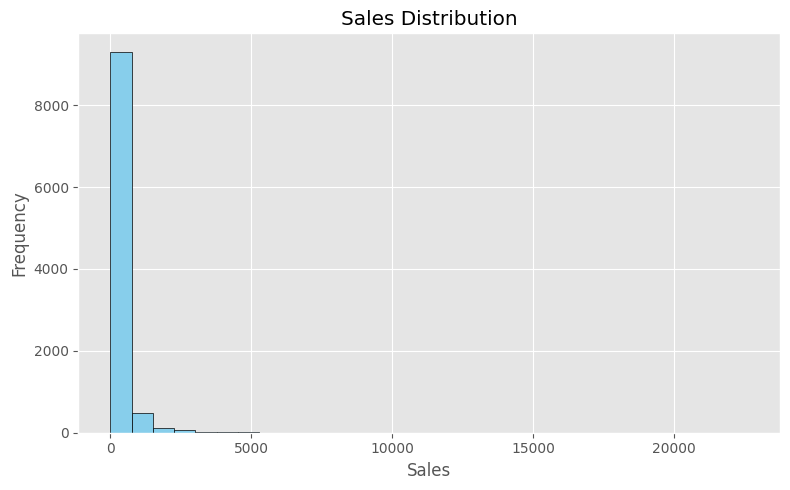

In [31]:
plt.figure(figsize=(8,5))

plt.hist(df["Sales"],bins=30,color="skyblue",edgecolor="black")
plt.title("Sales Distribution")

plt.xlabel("Sales")
plt.ylabel("Frequency")

plt.grid(True)
plt.tight_layout()

plt.savefig("../visualizations/histogram.png")
plt.show()

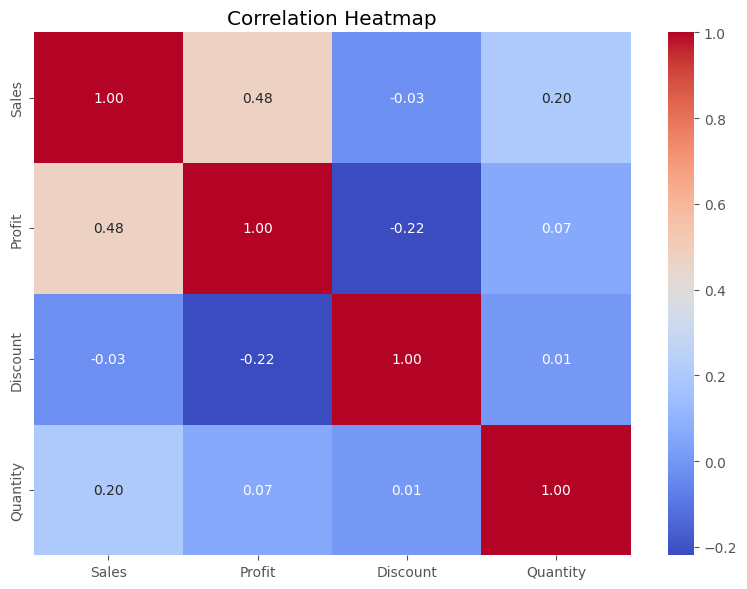

In [32]:
plt.figure(figsize=(8,6))

sns.heatmap(df[["Sales","Profit","Discount","Quantity"]].corr(),annot=True,cmap="coolwarm",fmt=".2f")

plt.title("Correlation Heatmap")
plt.tight_layout()

plt.savefig("../visualizations/heatmap.png")

plt.show()


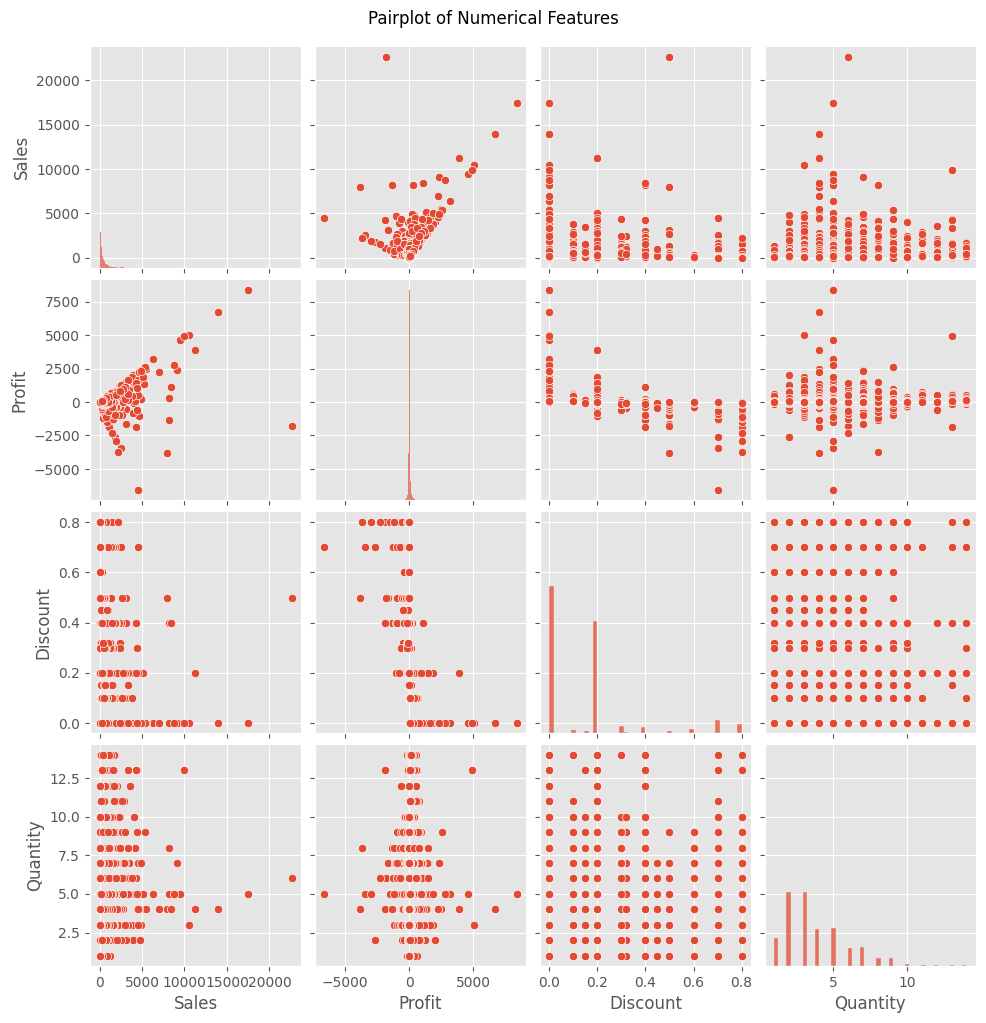

In [33]:
pair_plot=sns.pairplot(df[["Sales","Profit","Discount","Quantity"]])
pair_plot.figure.suptitle("Pairplot of Numerical Features",y=1.02)

pair_plot.savefig("../visualizations/pairplot.png")
plt.show()

C:\Users\Priti\AppData\Local\Temp\ipykernel_21640\819564045.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(


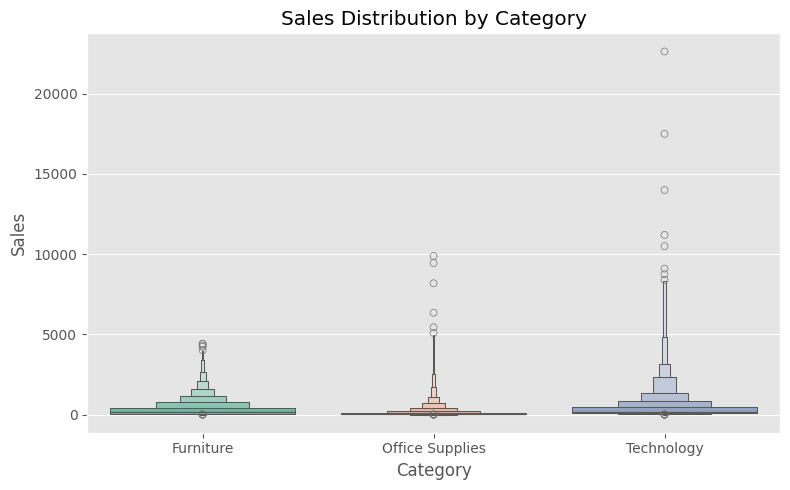

In [36]:
plt.figure(figsize=(8,5))

sns.boxenplot(
    x="Category",
    y="Sales",
    data=df,
    palette="Set2"
)

plt.title("Sales Distribution by Category")
plt.xlabel("Category")
plt.ylabel("Sales")

plt.tight_layout()

plt.savefig("../visualizations/boxen_plot.png")

plt.show()

In [38]:
monthly_sales = df.groupby("Month")["Sales"].sum().reset_index()

monthly_sales["Month"] = monthly_sales["Month"].astype(str)

fig = px.line(
    monthly_sales,
    x="Month",
    y="Sales",
    title="Interactive Monthly Sales Trend",
    markers=True
)

fig.write_html("../visualizations/interactive_sales_trend.html")

fig.show()